<a href="https://colab.research.google.com/github/Mirajul100/Machine-Learning/blob/master/Emotions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [353]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [354]:
import re

In [355]:
df = pd.read_csv('merged_file.txt' , sep=';' , header=None , names=['text' , 'emotion'])

In [356]:
df.head(5)

,text,emotion
0,im feeling rather rotten so im not very ambiti...,sadness
1,im updating my blog because i feel shitty,sadness
2,i never make her separate from me because i do...,sadness
3,i left with my bouquet of red and yellow tulip...,joy
4,i was feeling a little vain when i did this one,sadness


In [357]:
df.shape

(20000, 2)

In [358]:
df.isnull().sum()

,0
text,0
emotion,0


In [359]:
df.duplicated().sum()

np.int64(1)

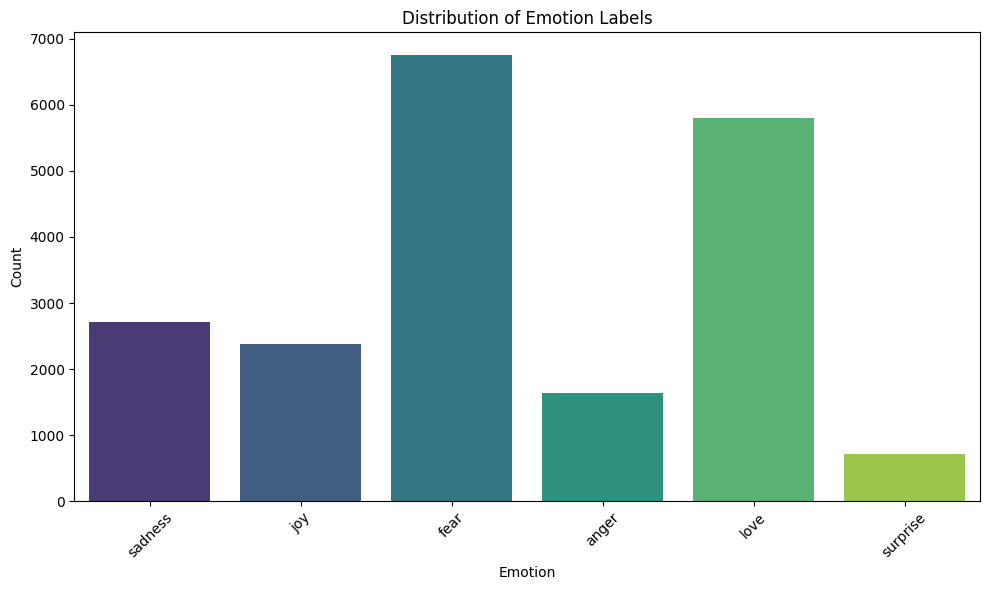

In [360]:
emotion_counts = df['emotion'].value_counts().sort_index()
emotion_labels = df['emotion'].unique()

plt.figure(figsize=(10, 6))
sns.barplot(x=emotion_labels, y=emotion_counts.values, palette='viridis')
plt.title('Distribution of Emotion Labels')
plt.xlabel('Emotion')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [361]:
from sklearn.preprocessing import LabelEncoder

In [362]:
encode = LabelEncoder()

In [363]:
encode.fit(df['emotion'])

LabelEncoder()

In [364]:
df['emotion'] = encode.transform(df['emotion'])

In [365]:
df.head(5)

,text,emotion
0,im feeling rather rotten so im not very ambiti...,4
1,im updating my blog because i feel shitty,4
2,i never make her separate from me because i do...,4
3,i left with my bouquet of red and yellow tulip...,2
4,i was feeling a little vain when i did this one,4


# Convert text into lowercase

In [366]:
df['text'] = df['text'].str.lower()

In [367]:
df.head(5)

,text,emotion
0,im feeling rather rotten so im not very ambiti...,4
1,im updating my blog because i feel shitty,4
2,i never make her separate from me because i do...,4
3,i left with my bouquet of red and yellow tulip...,2
4,i was feeling a little vain when i did this one,4


# Remove punctuations

In [368]:
df['text'] = df['text'].str.replace('[^\w\s]' , '' , regex=True)

# Remove digits

In [369]:
def remove_digits(text):
  new = ''
  for i in text:
    if not i.isdigit():
      new = new + i
  return new

In [370]:
df['text'] = df['text'].apply(remove_digits)

# Remove emojis

In [371]:
def remove_emoji(text):
  new = ''
  for i in text:
    if i.isascii():
      new = new + i
  return new

In [372]:
df['text'] = df['text'].apply(remove_emoji)

# Remove link

In [373]:
import re

In [374]:
def remove_link(text):
  return re.sub(r'http\S+' , '' , text)

In [375]:
df['text'] = df['text'].apply(remove_link)

# Remove html tags

In [376]:
def remove_tags(text):
 text = re.sub(r'<.*?>', '', text)
 return text

In [377]:
df['text'] = df['text'].apply(remove_tags)

# Remove stop words

In [378]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

In [379]:
nltk.download('stopwords')
nltk.download('punkt_tab')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [380]:
stop_words = set(stopwords.words('english'))
len(stop_words)

198

In [381]:
def remove_stopwords(text):
 word = word_tokenize(text)
 new = []
 for i in word:
   if i not in stop_words:
     new.append(i)
 return ' '.join(new)

In [382]:
df['text'] = df['text'].apply(remove_stopwords)

In [383]:
df.head(5)

,text,emotion
0,im feeling rather rotten im ambitious right,4
1,im updating blog feel shitty,4
2,never make separate ever want feel like ashamed,4
3,left bouquet red yellow tulips arm feeling sli...,2
4,feeling little vain one,4


### Distribution of Emotion Labels

In [384]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.stats import uniform

In [385]:
X = df['text']
y = df['emotion']

In [386]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [387]:
bow_vectorizer = CountVectorizer(max_df=0.9,
                                 max_features=10000,
                                 min_df=2,
                                 ngram_range=(1, 2))
X_train_bow = bow_vectorizer.fit_transform(X_train)
X_test_bow = bow_vectorizer.transform(X_test)

In [388]:
model_nb = MultinomialNB()
model_nb.fit(X_train_bow, y_train)

MultinomialNB()

In [389]:
y_pre_bow = model_nb.predict(X_test_bow)
acc = accuracy_score(y_test , y_pre_bow)
print(acc)

0.8472727272727273


In [390]:
tfidf_vectorizer = TfidfVectorizer(ngram_range= (1, 1),
                                   min_df= 5,
                                   max_features= 10000,
                                   max_df= 0.8)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

In [391]:
model_nb = MultinomialNB()
model_nb.fit(X_train_tfidf, y_train)

MultinomialNB()

In [392]:
y_pre_tfidf = model_nb.predict(X_test_tfidf)
acc = accuracy_score(y_test , y_pre_tfidf)
print(acc)

0.7603030303030303


In [393]:
model_lo_bow = LogisticRegression(C= 10, penalty= 'l2', solver= 'liblinear')
model_lo_bow.fit(X_train_bow, y_train)

LogisticRegression(C=10, solver='liblinear')

In [394]:
y_pre_bow = model_lo_bow.predict(X_test_bow)
acc = accuracy_score(y_test , y_pre_bow)
print(acc)

0.896969696969697


### Save the best performing model and its vectorizer

In [395]:
model_lo_tfidf = LogisticRegression(C= 10, penalty= 'l2', solver= 'liblinear')
model_lo_tfidf.fit(X_train_tfidf, y_train)

LogisticRegression(C=10, solver='liblinear')

In [396]:
y_pre_tfidf = model_lo_tfidf.predict(X_test_tfidf)
acc = accuracy_score(y_test , y_pre_tfidf)
print(acc)

0.8854545454545455


In [397]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline

In [398]:
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l2'],
    'solver': ['liblinear', 'lbfgs']
}

In [399]:
grid = GridSearchCV(
    estimator=model_lo,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

In [400]:
grid.fit(X_train_bow, y_train)
print("Best Params:", grid.best_params_)
print("Best Score:", grid.best_score_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Params: {'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}
Best Score: 0.9011194029850745


In [401]:
grid.fit(X_train_tfidf, y_train)
print("Best Params:", grid.best_params_)
print("Best Score:", grid.best_score_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Params: {'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}
Best Score: 0.8869402985074626


In [402]:
from xgboost import XGBClassifier

In [403]:
model_xg = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

In [404]:
model_xg.fit(X_train_tfidf, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [405]:
y_pre_tfidf = model_xg.predict(X_test_tfidf)
acc = accuracy_score(y_test , y_pre_tfidf)
print(acc)

0.7716666666666666


In [406]:
import pickle

with open('logistic_regression_bow_model.pkl', 'wb') as f:
    pickle.dump(model_lo_bow, f)
with open('count_vectorizer.pkl', 'wb') as f:
    pickle.dump(bow_vectorizer, f)
with open('logistic_regression_tfidf_model.pkl', 'wb') as f:
    pickle.dump(model_lo_tfidf, f)
with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf_vectorizer, f)

print("Logistic Regression model and CountVectorizer saved successfully.")

Logistic Regression model and CountVectorizer saved successfully.


In [407]:
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('clf', LogisticRegression(max_iter=1000))
])

In [408]:
param_rendom = {
    'tfidf__max_features': [5000, 10000, 20000],
    'tfidf__ngram_range': [(1,1), (1,2)],
    'tfidf__min_df': [1, 2, 5],
    'tfidf__max_df': [0.8, 0.9, 1.0],
    'clf__C': [0.01, 0.1, 1, 10],
    'clf__solver': ['liblinear', 'lbfgs']
}

In [409]:
random_search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_rendom,
    n_iter=20,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    random_state=42
)

In [410]:
random_search.fit(X_train, y_train)
print(random_search.best_params_)
print(random_search.best_score_)

{'tfidf__ngram_range': (1, 1), 'tfidf__min_df': 5, 'tfidf__max_features': 10000, 'tfidf__max_df': 0.8, 'clf__solver': 'liblinear', 'clf__C': 10}
0.8819353612146456


In [411]:
pipeline = Pipeline([
    ('bow', CountVectorizer()),
    ('clf', LogisticRegression(max_iter=1000))
])

In [412]:
param_dist = {
    'bow__max_features': [5000, 10000, 20000, None],
    'bow__ngram_range': [(1,1), (1,2), (1,3)],
    'bow__min_df': [1, 2, 5],
    'bow__max_df': [0.8, 0.9, 1.0],
    'clf__C': uniform(0.01, 10),
    'clf__solver': ['liblinear', 'lbfgs']
}

In [413]:
random_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=2,
    random_state=42
)

In [414]:
random_search.fit(X_train, y_train)
print(random_search.best_params_)
print(random_search.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
{'bow__max_df': 0.9, 'bow__max_features': 10000, 'bow__min_df': 2, 'bow__ngram_range': (1, 2), 'clf__C': np.float64(7.282719958564209), 'clf__solver': 'liblinear'}
0.9013244873914381
